In [1]:
from pathlib import Path
import sys
project_root = Path.cwd().parents[2]
sys.path.append(str(project_root))
from Modeling.models.beam_properties import PiezoBeamParams
import importlib
from Modeling.models.ROM import ROM
from Modeling.models.FE1 import PiezoBeamFE, frf_sweep, solve_newmark
# if 'ROM' in dir():
# 	importlib.reload(sys.modules['ROM'])

import numpy as np
from numpy import pi	
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from IPython.display import clear_output
from matplotlib import cm, colors
import pandas as pd


In [2]:

#%%

K_i = 0; K_p = 0.02; K_c = 0
t_end = 0.01
f0 = 1000; f1 = 8000
N = 40
j_exc = 30

def v_exc(t, A_exc=50, f0=f0, f1=f1, t_end=t_end):
	return A_exc*np.sin(2*np.pi*(f0+ t*(f1-f0)/t_end) *t)
params = PiezoBeamParams()
params.zeta_p = 0.0151/5
params.zeta_q = 0.0392/5
rom = ROM(params, N=N)
interface_idx = 4
beta = -0.3
# # ======= K_p sweep in frequency domain =======

ki0 = 4000
ki2 = ki0 / (1 - beta)**2 
ki1 = ki0 / (1 + beta)**2 
S = rom.S
K_i = np.zeros(S)
K_i = np.zeros(S)
for i in range(S):
	if i < interface_idx:
		K_i[i] = ki1 if i % 2 == 0 else ki2
	else:
		K_i[i] = ki2 if (i - interface_idx) % 2 == 0 else ki1

print("K_i:", K_i, )
#%%
# x_eval = np.linspace(0, rom.p.L_b, 1000)
# x0 = np.zeros(2*N + 2*S)


t_eval = np.arange(0, t_end, 1/f1/20)
x_eval = np.linspace(0, rom.p.L_b, 500)

results = rom.run_time_sim(v_exc=v_exc, j_exc=j_exc, K_c=K_c, K_p=K_p, K_i=K_i, t_end=t_end, x_eval=x_eval, t_eval=t_eval)
t = results['t']
veloc = results['veloc']
freq = results['freq']
Y = results['Y']
X = results['X']
FRF = results['FRF']

freq_modal, vel_mag, disp_mag, veloc_frq = rom.frequency_response(j_exc=j_exc, K_c=K_c, K_p=K_p, K_i=K_i,
										w=np.linspace(f0, f1, 200)*2*np.pi, x_eval=x_eval)


K_i: [8163.26530612 2366.86390533 8163.26530612 2366.86390533 2366.86390533
 8163.26530612 2366.86390533 8163.26530612 2366.86390533 8163.26530612
 2366.86390533 8163.26530612 2366.86390533 8163.26530612 2366.86390533
 8163.26530612 2366.86390533 8163.26530612 2366.86390533 8163.26530612
 2366.86390533 8163.26530612 2366.86390533 8163.26530612 2366.86390533
 8163.26530612 2366.86390533 8163.26530612 2366.86390533 8163.26530612
 2366.86390533]


First 5 natural frequencies (FE): [  5.31885089  33.33317995  93.32905293 182.87775138 302.29367823] Hz
Running time domain simulation with FE model...
Computing frequency response (FE)...
FE frequency response complete.


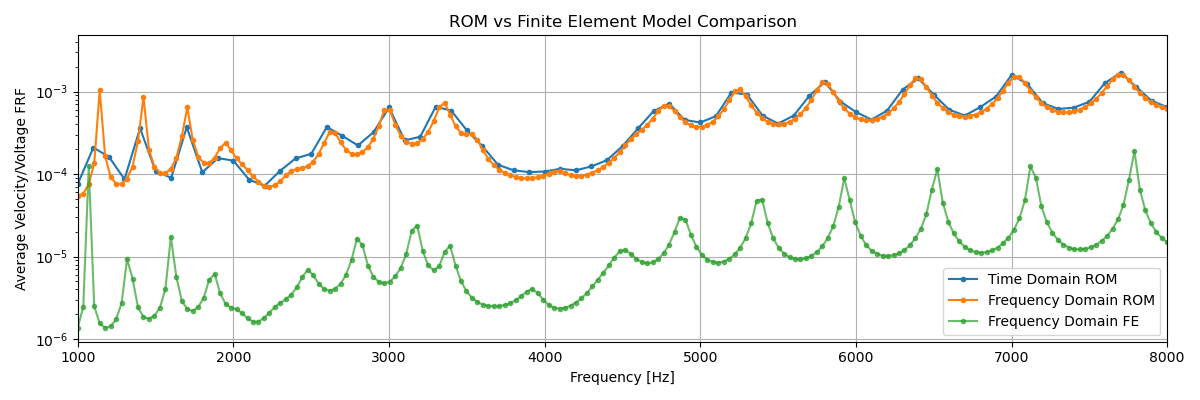

In [6]:
%matplotlib widget
# =================== Finite Element Analysis ===================
# Setup FE model with same parameters
params_fe = PiezoBeamParams()
params_fe.zeta_p = 0.0151/5
params_fe.zeta_q = 0.0392/5

# Create FE model
fe = PiezoBeamFE(params_fe)

# Perform eigenanalysis
freq_fe, omega_fe, Phi_fe = fe.eigen_analysis()
print(f"First 5 natural frequencies (FE): {freq_fe[:5]} Hz")

# Build ODE system for FE model
# Note: K_i in FE is scalar (applied to all patches except excitation)
# We'll use the mean K_i value from ROM setup
K_i_mean = np.mean(K_i)

ode_fe = fe.build_ode_system(
    j_exc=j_exc,
    A_exc=50.0,
    f0=f0,
    f1=f1,
    t_end=t_end,
    R_c=1e3,
    K_p=K_p,
    K_i=K_i,
    K_c=K_c
)

# =================== Time Domain Simulation (FE) ===================
print("Running time domain simulation with FE model...")
dt = 1/(f1*20)
# t_fe, x_fe, x_dot_fe, x_ddot_fe = solve_newmark(
#     ode_fe,
#     dt=dt,
#     t_end=t_end,
#     beta=0.25,
#     gamma=0.5,
#     newton_tol=1e-9,
#     newton_maxiter=5
# )

# # Extract mechanical DOFs (displacement)
N_mech = ode_fe.N_mech
# u_fe = x_fe[:, :N_mech]  # all mechanical DOFs
# w_fe = u_fe[:, ::2]      # transverse displacement only

# # Compute average velocity
# v_fe = x_dot_fe[:, :N_mech]
# v_w_fe = v_fe[:, ::2]    # transverse velocity only
# v_avg_fe = np.mean(np.abs(v_w_fe), axis=1)

# # FFT for frequency response
# dt_fe = t_fe[1] - t_fe[0]
# freq_fft_fe = np.fft.fftfreq(len(t_fe), d=dt_fe)
# V_fft_fe = np.fft.fft(v_avg_fe)

# # Keep positive frequencies
# idx_pos_fe = (freq_fft_fe >= f0) & (freq_fft_fe <= f1)
# freq_fft_fe_pos = freq_fft_fe[idx_pos_fe]
# V_mag_fe = np.abs(V_fft_fe[idx_pos_fe]) / (50.0)  # normalize by excitation amplitude

# print(f"FE time simulation complete. {len(t_fe)} time steps.")

# =================== Frequency Domain Analysis (FE) ===================
print("Computing frequency response (FE)...")
omega_sweep = np.linspace(f0, f1, 200) * 2 * np.pi
X_frf_fe = frf_sweep(ode_fe, omega_sweep)

# Extract mechanical response
U_frf_fe = X_frf_fe[:, :N_mech]
w_frf_fe = U_frf_fe[:, ::2]

# Compute average velocity magnitude
vel_mag_fe = np.abs(w_frf_fe * (omega_sweep[:, np.newaxis] * 1j)).mean(axis=1) / 50.0
freq_sweep_fe = omega_sweep / (2 * np.pi)

print("FE frequency response complete.")

# =================== Plot Comparison: ROM vs FE ===================
plt.figure(figsize=(12, 4))
plt.semilogy(freq, FRF, '.-', linewidth=1.5, label='Time Domain ROM')
plt.semilogy(freq_modal, vel_mag, '.-', label='Frequency Domain ROM')
# plt.semilogy(freq_fft_fe_pos, V_mag_fe, 's-', linewidth=1.5, markersize=3, label='Time Domain FE', alpha=0.7)
plt.semilogy(freq_sweep_fe, vel_mag_fe, 'o-', markersize=3, label='Frequency Domain FE', alpha=0.7)
plt.legend()
plt.xlim([f0, f1])
plt.xlabel("Frequency [Hz]")
plt.ylabel("Average Velocity/Voltage FRF")
plt.title("ROM vs Finite Element Model Comparison")
plt.grid(True)
plt.tight_layout()
plt.show()


In [4]:
# %matplotlib widget

In [5]:

# Load experimental data
npz_path_OC = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\7\kc0_kp_sweep\OCSC\OC.npz".replace("\\", "/")
# npz_path_linear =r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\10\ki0_kc0_kpSweep\parametric_sweep.npz".replace("\\", "/")  
npz_path_linear =r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\linear.npz".replace("\\", "/")  
# npz_path_OC =r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\OC.npz".replace("\\", "/")
npz_path_SC = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\7\kc0_kp_sweep\OCSC\SC.npz".replace("\\", "/")
data_SC = np.load(npz_path_SC)
data_OC = np.load(npz_path_OC)
data_linear = np.load(npz_path_linear)

frq_OC_exp = data_OC['freq']			# (Nfreq,)
frf_data_OC_exp = data_OC['frf_data']	# (Nfiles, Nfreq, Npoints)
frq_SC_exp = data_SC['freq']            # (Nfreq,)
frf_data_SC_exp = data_SC['frf_data']   # (Nfiles, Nfreq, Npoints)
frq_linear_exp = data_linear['freq']            # (Nfreq,)
frf_data_linear_exp = data_linear['frf_data']
comsol_OC = pd.read_csv(os.path.join(project_root, 'comsol/OC.csv'))
#%%
plt.figure(figsize=(12, 4))
# plt.semilogy(frq_linear_exp, np.mean(frf_data_linear_exp[:,:], axis=1), 'r--', label=' Experiment')
# plt.semilogy(comsol_OC['freq'], comsol_OC['w']*2*pi*comsol_OC['freq'], 'g-', label='COMSOL ')
# plt.semilogy(comsol_OC['freq'], comsol_OC['w'], 'g-', label='COMSOL displacement FRF')
# plt.semilogy(frq_OC_exp, np.mean(frf_data_OC_exp[:,:], axis=1), 'k--', label=f'Open circuit Exp.')
# plt.semilogy(frq_SC_exp, np.mean(frf_data_SC_exp[:,:], axis=1), 'b--', label=f'Short circuit Exp.')
# plt.semilogy(freq_modal, vel_mag, '.-', label='Modal Reduced Order'   )
plt.semilogy(freq, FRF, '.-', linewidth=1.5, label='Time Domain ROM')
plt.semilogy(freq_modal, vel_mag, '.-', label='Frequency Domain ROM'   )
# plt.semilogy(frq_OC_exp, np.mean(frf_data_OC_exp[:,:], axis=1), 'k--', label=f'Experiment')
# plt.semilogy(frq_linear, np.mean(frf_data_linear[:,:], axis=1), 'r--', label=' Exp.')

# plt.semilogy(freq_modal, disp_mag*freq_modal*2*np.pi, '-', label='Modal Reduced Order Displacement $j \omega$'   )
plt.legend()
# plt.xlim([1300, 3000])
plt.xlim([f0, f1])
# plt.ylim([1e-5, 1e-3])
# plt.ylim([3e-5, 6e-4])
plt.xlabel("Frequency [Hz]")
plt.ylabel("AverageVelocity/Voltage FRF")
plt.grid(True)
plt.show()





# plt.figure()

# # plt.plot(t, disp[10,:], '.-', label='Disp.')
# plt.plot(t, veloc[10,:], '-', label='Velocity')
# # plt.xlim([0, 0.05 ])
# # plt.ylim(np.array([-1,1])*1e-3)

# plt.xlabel("t [s]")
# # plt.ylabel("displacement")
# plt.legend()
# plt.grid(True)
#%%
# =================== Spectral analysis: v(x, freq) heatmap ===================
# Perform FFT along time axis to get frequency content at each spatial location
dt = t[1] - t[0]  # time step
fs = 1.0 / dt  # sampling frequency

# FFT along time axis (axis=1)
V_freq = np.fft.fft(veloc, axis=1)

# Frequency vector
freq_fft = np.fft.fftfreq(len(t), d=dt)

# Keep only positive frequencies
idx_pos = freq_fft >= 0
freq_fft_pos = freq_fft[idx_pos]
V_freq_pos = V_freq[:, idx_pos]

# Magnitude spectrum
V_mag = np.abs(V_freq_pos)

# Plot heatmap with frequency on y-axis
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_eval, freq_fft_pos, V_mag.T, shading='auto', cmap='viridis')
plt.colorbar(label='|V(x, f)| [m/s]')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Position along beam [m]')
plt.title('Spatial-Frequency Velocity Spectrum')
plt.ylim([0, f1])  # Adjust frequency range as needed
plt.tight_layout()
plt.show()
# %%


NameError: name 'os' is not defined

c:\ProgramData\anaconda3\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\ProgramData\anaconda3\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


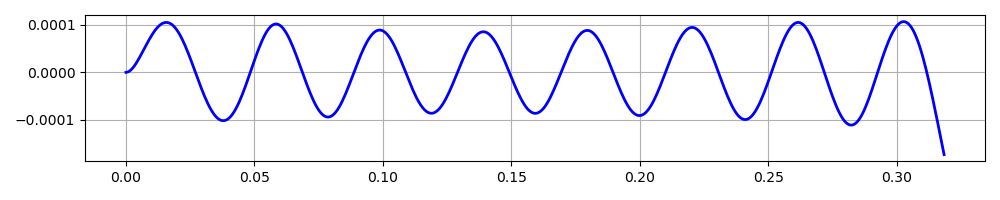

In [ ]:

# =================== Mode shape at single frequency ===================
single_freq = np.array([3650])
  # Hz - choose your frequency of interest
single_w = single_freq * 2 * np.pi
x_eval_mode = np.linspace(0, rom.p.L_b, 500)

# Get frequency response at single frequency
freq_single, vel_mag_single, disp_mag_single, veloc_frq = rom.frequency_response(
    K_c=K_c, K_p=K_p, K_i=K_i, w=single_w, x_eval=x_eval_mode
)

# veloc_frq has shape (n_spatial_points, 1) - extract the mode shape

# Plot the mode shape
plt.figure(figsize=(10, 2))
plt.plot(x_eval_mode,  veloc_frq[:, 0], 'b-', linewidth=2)
# plt.xlabel('Position along beam [m]')
# plt.ylabel('Velocity magnitude [m/s]')
# plt.title(f'Mode shape at {single_freq} Hz')
plt.grid(True)
plt.tight_layout()
plt.show()
# %%


In [ ]:
veloc_frq.shape

(500, 1)

ValueError: x and y must have same first dimension, but have shapes (158,) and (157,)

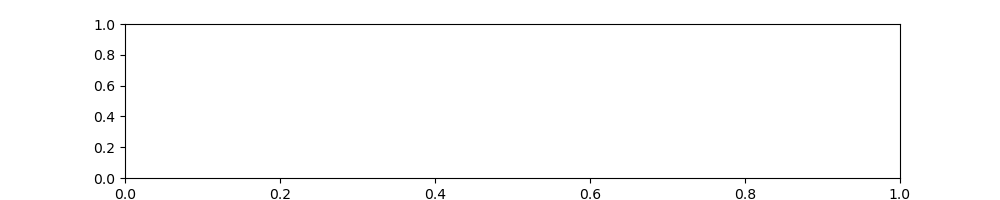

In [ ]:
# =================== FE Mode shape at single frequency ===================
# Uses FE frequency response to plot the spatial mode shape (velocity) at a chosen frequency

# Try to reuse the same target frequency as ROM cell, fallback if missing
try:
    f_target = float(single_freq[0])
except Exception:
    f_target = 3371.0  # Hz

# Ensure FE objects exist
assert 'fe' in globals() and 'ode_fe' in globals(), "FE model not initialized. Run the FE analysis cell first."

# Reduced mechanical displacement DOFs correspond to nodes 1..end (node 0 clamped)
x_coords_fe = fe.x_nodes[1:]

# If FE FRF sweep exists, sample nearest; otherwise compute single-frequency FRF
if 'w_frf_fe' in globals() and 'freq_sweep_fe' in globals():
    idx_near = np.argmin(np.abs(freq_sweep_fe - f_target))
    w_hat_nodes = w_frf_fe[idx_near, :]  # displacement at reduced nodes (complex)
    omega_t = 2*np.pi*freq_sweep_fe[idx_near]
else:
    omega_t = 2*np.pi*f_target
    X_single = frf_sweep(ode_fe, np.array([omega_t]))[0]
    N_mech = ode_fe.N_mech
    w_hat_nodes = X_single[:N_mech][::2]

# Velocity (complex) = i*omega * displacement
v_hat_nodes = 1j * omega_t * w_hat_nodes

# Plot real part, normalized for shape clarity (sign preserved)
v_plot = np.real(v_hat_nodes)
max_abs = np.max(np.abs(v_plot))
if max_abs > 0:
    v_plot = v_plot / max_abs

plt.figure(figsize=(10, 2))
plt.plot(x_coords_fe, v_plot, 'r-', linewidth=2)
# plt.xlabel('Position along beam [m]')
# plt.ylabel('Normalized velocity (real)')
# plt.title(f'FE Mode shape at {f_target:.1f} Hz')
plt.grid(True)
plt.tight_layout()
plt.show()